# LedgerFlow — Exploratory Data Analysis

Explores the raw event log produced by the DVC `ingest` stage (`data/raw/events.parquet`) and the per-user labels. Run `dvc repro` first if the data files are missing.

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "params.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("project root:", ROOT)


project root: /Users/chetan/LedgerFlow


In [2]:
events = pd.read_parquet(ROOT / 'data/raw/events.parquet')
labels = pd.read_parquet(ROOT / 'data/raw/labels.parquet')
print('events:', events.shape, '| users:', events.user_id.nunique())
events.head()

events: (33239, 6) | users: 2000


,event_id,user_id,event_type,event_timestamp,amount,session_id
0,evt_00000000,user_000000,click,2024-01-01 14:39:55,NaN,sess_000000_000
1,evt_00000001,user_000000,view,2024-01-02 12:02:51,NaN,sess_000000_000
2,evt_00000002,user_000000,view,2024-01-04 17:54:35,NaN,sess_000000_000
3,evt_00000003,user_000000,login,2024-01-05 05:52:12,NaN,sess_000000_000
4,evt_00000004,user_000000,view,2024-01-05 07:04:46,NaN,sess_000000_000


## Event-type distribution

event_type
view        10140
purchase     9976
login        6624
click        6499
Name: count, dtype: int64


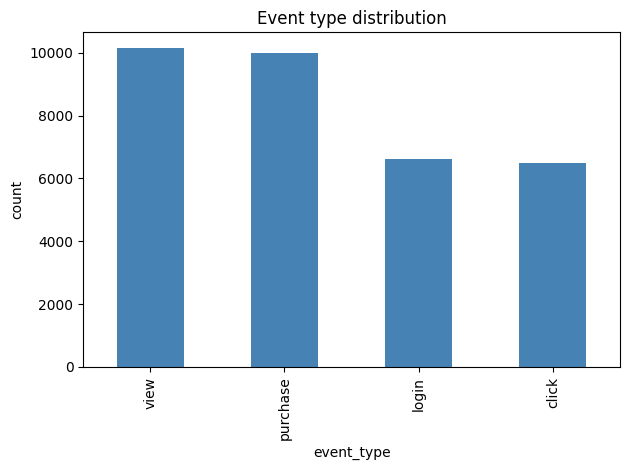

In [3]:
counts = events.event_type.value_counts()
print(counts)
ax = counts.plot.bar(title='Event type distribution', color='steelblue')
ax.set_ylabel('count'); plt.tight_layout(); plt.show()

## Event volume over time (daily)

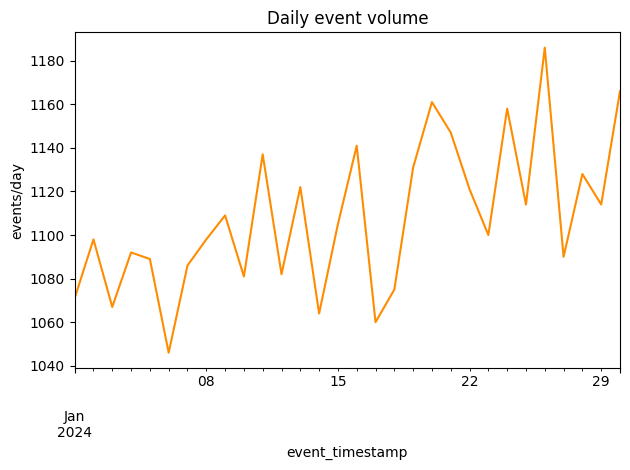

In [4]:
daily = events.set_index('event_timestamp').resample('1D').size()
ax = daily.plot(title='Daily event volume', color='darkorange')
ax.set_ylabel('events/day'); plt.tight_layout(); plt.show()

## Purchase amount distribution

count    9976.000000
mean       33.540258
std        47.548080
min         0.610000
25%        10.360000
50%        19.935000
75%        38.900000
max      1520.690000
Name: amount, dtype: float64


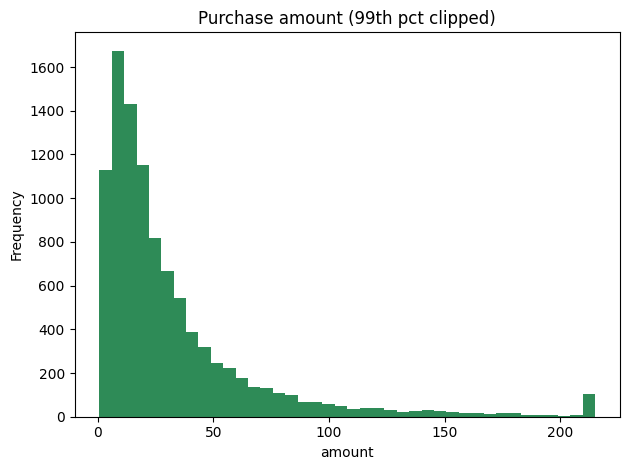

In [5]:
amt = events.loc[events.event_type=='purchase', 'amount'].dropna()
print(amt.describe())
ax = amt.clip(upper=amt.quantile(0.99)).plot.hist(bins=40, color='seagreen')
ax.set_title('Purchase amount (99th pct clipped)'); ax.set_xlabel('amount')
plt.tight_layout(); plt.show()

## Label balance

label
0    1321
1     679
Name: count, dtype: int64 
positive rate: 0.34


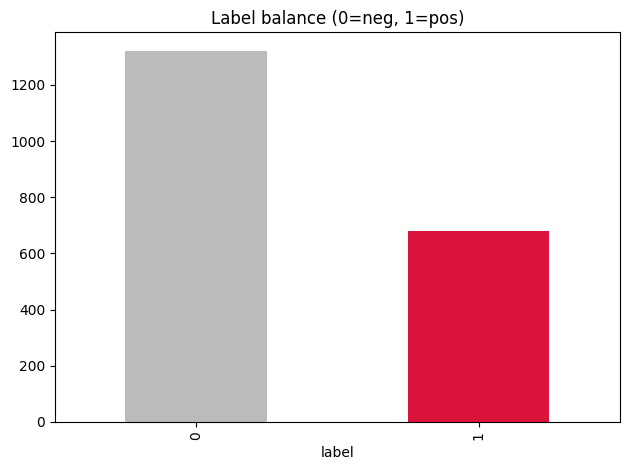

In [6]:
lc = labels.label.value_counts().sort_index()
print(lc, '\npositive rate:', round(labels.label.mean(), 3))
ax = lc.plot.bar(title='Label balance (0=neg, 1=pos)', color=['#bbb','crimson'])
plt.tight_layout(); plt.show()

## Events per user

count    2000.000000
mean       16.619500
std        11.391163
min         1.000000
25%         8.000000
50%        14.000000
75%        22.000000
max        81.000000
dtype: float64


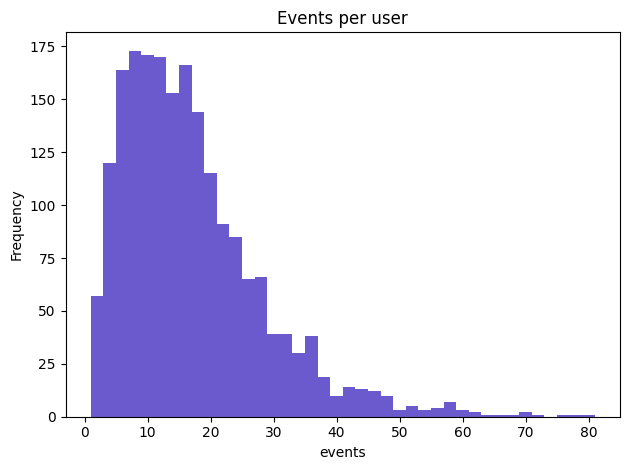

In [7]:
per_user = events.groupby('user_id').size()
print(per_user.describe())
ax = per_user.plot.hist(bins=40, color='slateblue')
ax.set_title('Events per user'); ax.set_xlabel('events')
plt.tight_layout(); plt.show()